In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [3]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

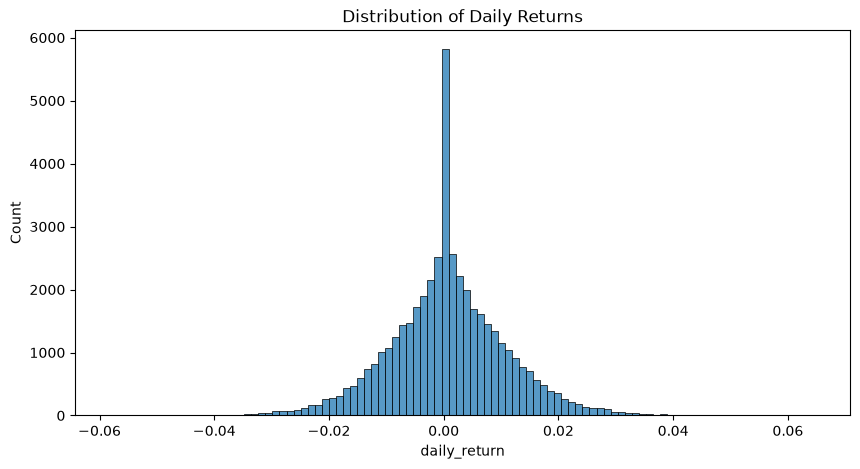

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.show()

In [5]:
def cagr(start,end,years):
    return (end/start)**(1/years)-1

In [6]:
rows=[]

for code,df in nav.groupby("amfi_code"):

    df=df.sort_values("date")

    if len(df)<252:
        continue

    end=df.iloc[-1]["nav"]

    one=df.iloc[-252]["nav"] if len(df)>=252 else np.nan
    three=df.iloc[-756]["nav"] if len(df)>=756 else np.nan
    five=df.iloc[-1260]["nav"] if len(df)>=1260 else np.nan

    rows.append({

        "amfi_code":code,

        "CAGR_1Y":
        cagr(one,end,1)
        if pd.notna(one) else np.nan,

        "CAGR_3Y":
        cagr(three,end,3)
        if pd.notna(three) else np.nan,

        "CAGR_5Y":
        cagr(five,end,5)
        if pd.notna(five) else np.nan

    })

cagr_table=pd.DataFrame(rows)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [7]:
rf=0.065

In [8]:
sharpe=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    annual_return=r.mean()*252

    annual_vol=r.std()*np.sqrt(252)

    ratio=(annual_return-rf)/annual_vol

    sharpe.append({

        "amfi_code":code,

        "Sharpe":ratio

    })

sharpe=pd.DataFrame(sharpe)

sharpe.sort_values(
    "Sharpe",
    ascending=False
).head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [9]:
sortino=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-rf)/downside_std

    sortino.append({

        "amfi_code":code,

        "Sortino":ratio

    })

sortino=pd.DataFrame(sortino)

In [15]:
nifty=pd.read_csv("../data/raw/HDFC_Top100_live.csv")

nifty["date"]=pd.to_datetime(
    nifty["date"], format="%d-%m-%Y"
)

nifty["benchmark_return"]=(
    nifty["nav"]
    .pct_change()
)

In [16]:
alpha_beta=[]

for code,df in nav.groupby("amfi_code"):

    merged=df.merge(
        nifty,
        on="date"
    )

    merged=merged.dropna()

    slope,intercept,r,p,se=linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha_beta.append({

        "amfi_code":code,

        "Alpha":
        intercept*252,

        "Beta":
        slope

    })

alpha_beta=pd.DataFrame(alpha_beta)

In [19]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [20]:
draw=[]

for code,df in nav.groupby("amfi_code"):

    df=df.sort_values("date")

    running_max=df["nav"].cummax()

    dd=df["nav"]/running_max-1

    draw.append({

        "amfi_code":code,

        "Max_Drawdown":dd.min()

    })

draw=pd.DataFrame(draw)

In [21]:
score=(
    cagr_table
    .merge(sharpe,on="amfi_code")
    .merge(alpha_beta,on="amfi_code")
    .merge(draw,on="amfi_code")
)

In [23]:
performance=pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

score=score.merge(

    performance[
        ["amfi_code","expense_ratio_pct"]
    ],

    on="amfi_code"
)

In [25]:
score["ReturnRank"]=score[
    "CAGR_3Y"
].rank(pct=True)

score["SharpeRank"]=score[
    "Sharpe"
].rank(pct=True)

score["AlphaRank"]=score[
    "Alpha"
].rank(pct=True)

score["ExpenseRank"]=(
    1-score["expense_ratio_pct"].rank(pct=True)
)

score["DrawRank"]=(
    1-score["Max_Drawdown"].rank(pct=True)
)

In [26]:
score["FundScore"]=100*(
0.30*score["ReturnRank"]+
0.25*score["SharpeRank"]+
0.20*score["AlphaRank"]+
0.15*score["ExpenseRank"]+
0.10*score["DrawRank"]
)

In [27]:
score.to_csv(
"../data/processed/fund_scorecard.csv",
index=False
)

In [28]:
top5=score.nlargest(
5,
"FundScore"
)["amfi_code"]

In [29]:
top=nav[
    nav["amfi_code"].isin(top5)
]

In [ ]:
fig=px.line(

top,

x="date",

y="nav",

color="amfi_code",

title="Top Funds vs Benchmark"

)

fig.show()

fig.write_image(
"../reports/charts/benchmark_comparison.png"
)

C:\Users\YASH BANSAL\AppData\Local\Temp\ipykernel_8828\1406970964.py:17: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(


In [3]:
import pandas as pd
import numpy as np

# Load data
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

# Parse dates
nav["date"] = pd.to_datetime(nav["date"])

# Sort and compute daily returns
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Load and prepare nifty benchmark
nifty = pd.read_csv("../data/raw/HDFC_Top100_live.csv")
nifty["date"] = pd.to_datetime(nifty["date"], format="%d-%m-%Y")
nifty = nifty.sort_values("date").reset_index(drop=True)
nifty["benchmark_return"] = nifty["nav"].pct_change()

print("nav shape:", nav.shape)
print("nifty shape:", nifty.shape)


nav shape: (46000, 4)
nifty shape: (3112, 3)


In [6]:
import pandas as pd
import os

files = {
    "AUM":          "../data/processed/aum_history.csv",
    "Transactions": "../data/processed/investor_transactions_cleaned.csv",
    "NAV":          "../data/processed/nav_history_cleaned.csv",
    "Performance":  "../data/processed/scheme_performance_cleaned.csv",
}

for name, path in files.items():
    if not os.path.exists(path):
        print(f"\n{name}: FILE NOT FOUND → {path}")
        continue
    df = pd.read_csv(path)
    print(f"\n{name} ({df.shape[0]} rows × {df.shape[1]} cols)")
    print(df.columns.tolist())



AUM (90 rows × 7 cols)
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year', 'aum_cr']

Transactions (32778 rows × 13 cols)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

NAV (46000 rows × 3 cols)
['amfi_code', 'date', 'nav']

Performance (40 rows × 19 cols)
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
